In [1]:
%matplotlib inline
import warnings

warnings.filterwarnings("ignore")

from benchmark_nonlinear import NonLinearIndicatorTester, NonLinearVisualizer
from benchmark_nonlinear import NonLinearDatasetGenerator
from calibration_sweep import BaselineCalibrator

calibrator = BaselineCalibrator(n_samples=500, n_splits=5)

use_hard_constraint = True
var_lower_bound = 1.0
var_upper_bound = 1.0

# Maximal Correlation: Non-Linear Benchmarks

## The Core Objective

The purpose of this benchmark is to empirically validate the capacity of the Kernel-based Maximal Correlation (HGR) algorithm to detect dependencies that standard statistical metrics fail to capture. Pearson's $r$ measures only global linear covariance and produces near-zero correlations on folded, periodic, or radial manifolds where non-linear structure dominates. Here, we benchmark a constrained Single-Kernel baseline (HGR-SK) against the Double-Kernel architecture (HGR-DK) across 13 distinct mathematical topologies, each chosen to probe different geometric constraints and algorithmic strengths.

## Head-to-Head Evaluation (SK vs DK)

We utilize a 5-fold cross-validation strategy to prevent overfitting and ensure generalization across data splits. The evaluation framework automatically flags performance plateaus indicating geometric ceilings, excessive overfitting gaps suggesting regularization failures, or near-zero scores on independent noise validating statistical rigor.

## Mathematical Methodology: Copulas and Structural Validation

### The Copula Transformations ($f(A)$ and $g(B)$)

Rather than fitting a linear relationship, the algorithm learns two separate non-linear transformations (copulas), $f(A)$ and $g(B)$, that map the original data into a new coordinate space where correlation is maximized. The HGR-SK baseline uses a single symmetric polynomial kernel to approximate both variables, constraining them to identical basis function families. The HGR-DK uses a Trust-Region optimizer to simultaneously approximate both variables with potentially asymmetric polynomial degrees (kernel_a and kernel_b), allowing independent flexibility for each dimension. This architectural distinction becomes critical on multi-valued manifolds where symmetric constraints introduce systematic bias.

### Empirical Performance Validation

Rather than visual-only analysis, validation is grounded in quantitative metrics:

1. **Correlation Scores:** Cross-validated test scores measure genuine structure detection, with interpretation benchmarked against problem-specific expectations (e.g., Circles should exceed 0.8 despite Pearson ≈ 0).

2. **Generalization Gap Analysis:** The difference between train and test scores reveals overfitting. Gaps <0.02 indicate excellent regularization; gaps >0.10 suggest the model is memorizing noise rather than capturing structure.

3. **Noise Rejection:** On independent Gaussian variables with zero true relationship, both algorithms should score near 0.0 (<0.1). Scores >0.3 would indicate false-positive hallucination—a critical failure mode.

4. **Saturation and Ceiling Detection:** By sweeping polynomial degrees 2-15, we identify whether performance improves monotonically (well-behaved), plateaus (geometric ceiling), or oscillates/degrades (pathological behavior like Runge's Phenomenon or overfitting).

### Topological Structure Preservation

A key validation question: does the algorithm successfully linearize folded manifolds without destroying their inherent structure? This is assessed through several mechanisms:

**Correlation Consistency:** For a manifold like Swiss Roll, if the algorithm genuinely unrolls the structure, correlation should remain stable across cross-validation folds (low std deviation). High variance across folds would indicate the algorithm is fitting noise rather than structure.

**Parametric Stability:** The learned parameters (optimal kernel degrees) should be consistent across different random data splits. Wildly varying optimal degrees would suggest the algorithm lacks robustness.

**Benchmark Coherence:** The algorithm should exhibit specialization—excellent performance on smooth functions (Sine, Polynomial), good performance on moderate manifolds (Moons, S-Curve), degraded but non-zero performance on hard manifolds (Swiss Roll, Circles), and near-zero performance on pure noise (Independent). This pattern proves geometric sensitivity rather than universal overfitting.

**Architectural Role:** DK should outperform SK specifically on multi-valued functions (Swiss Roll, Spiral, etc) while matching or underperforming on
single-valued smooth functions, demonstrating that asymmetric kernels provide genuine geometric advantage where needed, not universal superiority.



## The Topologies
We evaluate the algorithms against a variety of manifolds, continuous curves, and discontinuous step functions. Each dataset is injected with 10% Gaussian
noise to simulate real-world variance.

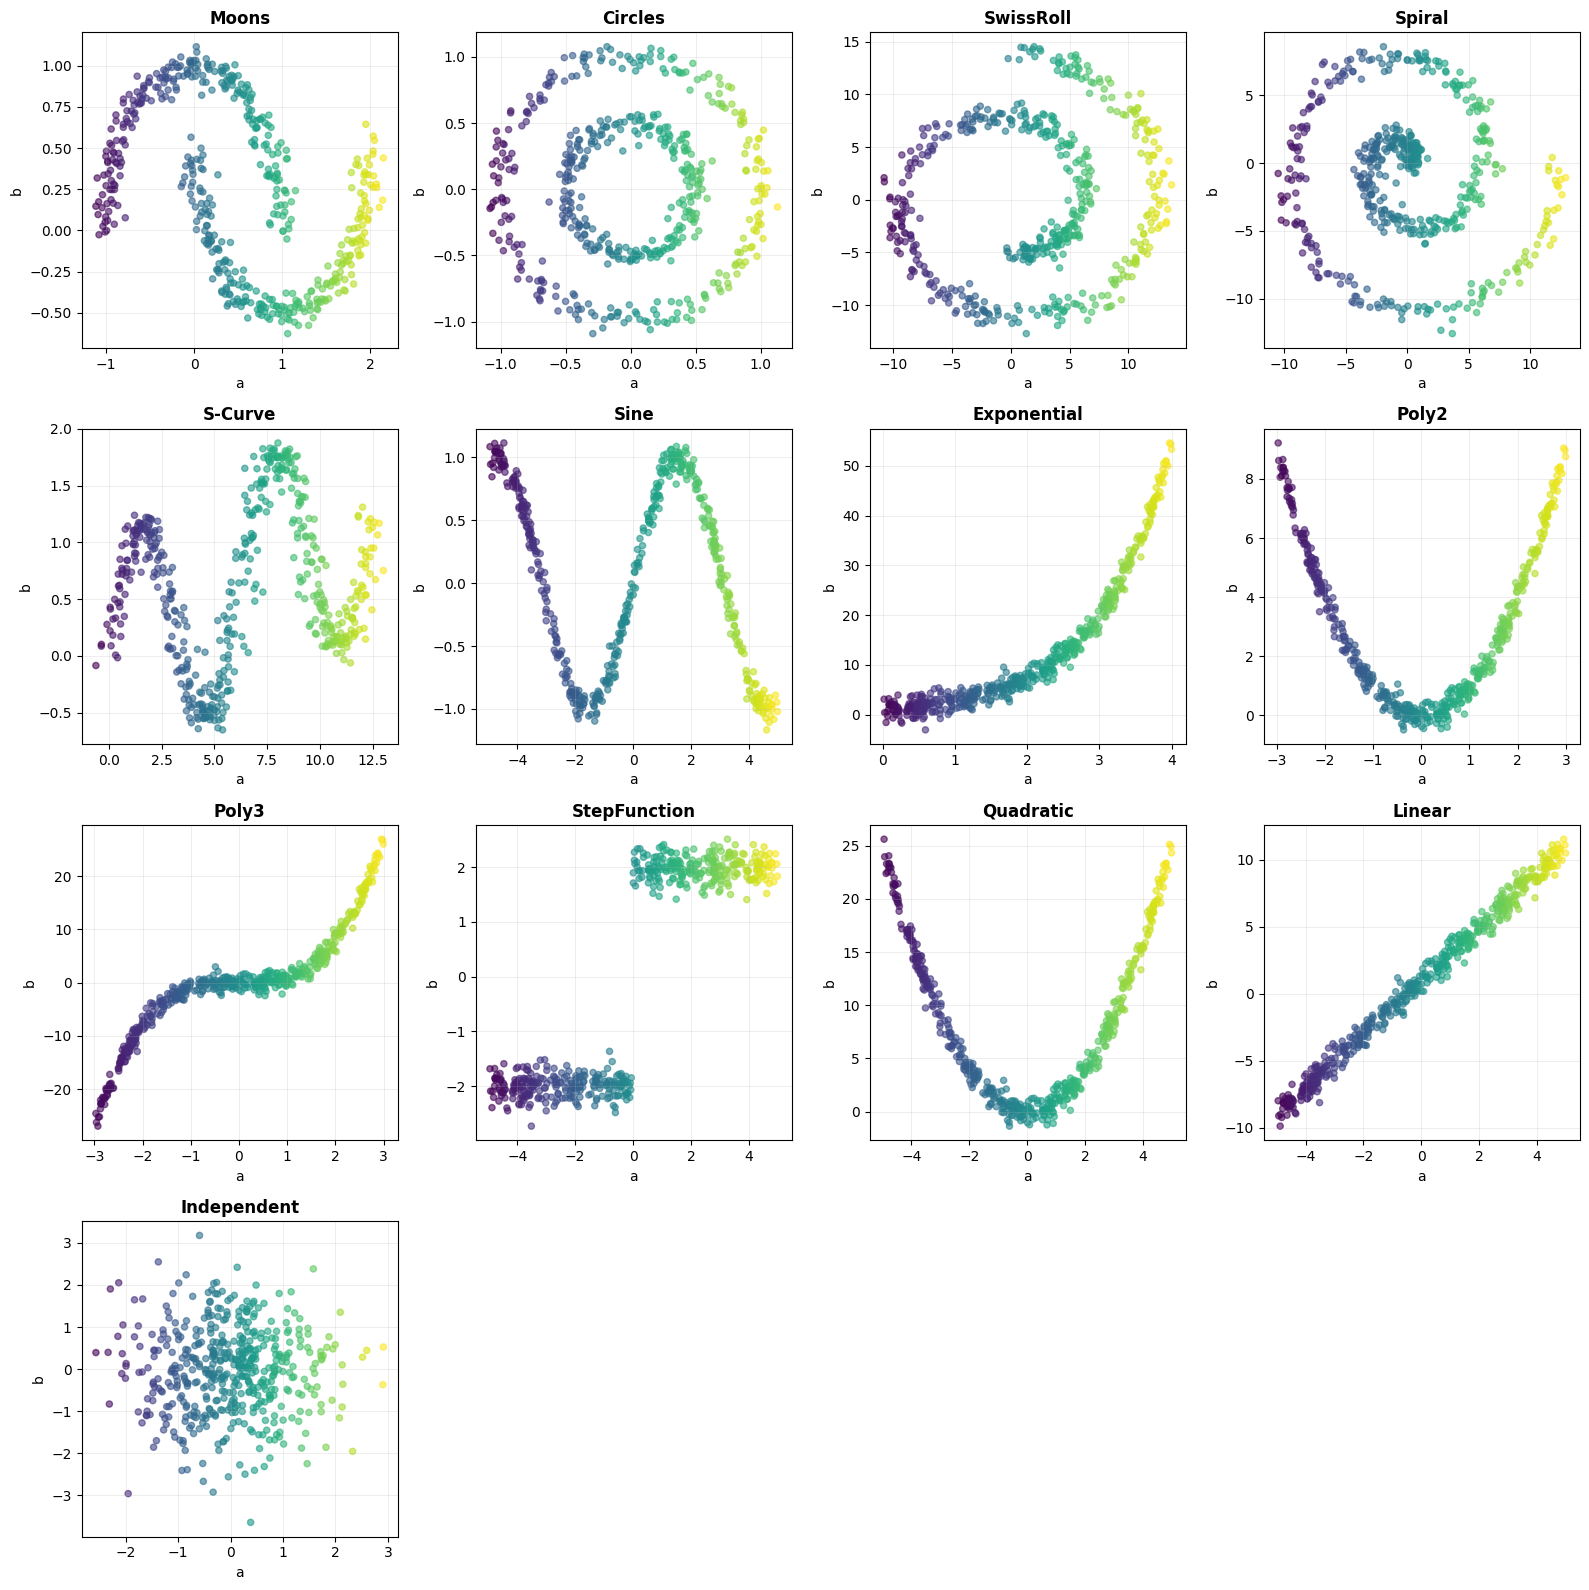

In [2]:
# Visualize the 13 synthetic datasets
NonLinearVisualizer.plot_datasets(n_samples=500, random_state=42)


Testing 13 Non-Linear Datasets

Testing 13 Datasets across 2 Algorithms

Generating Visual Proofs from Cross-Validation Results...


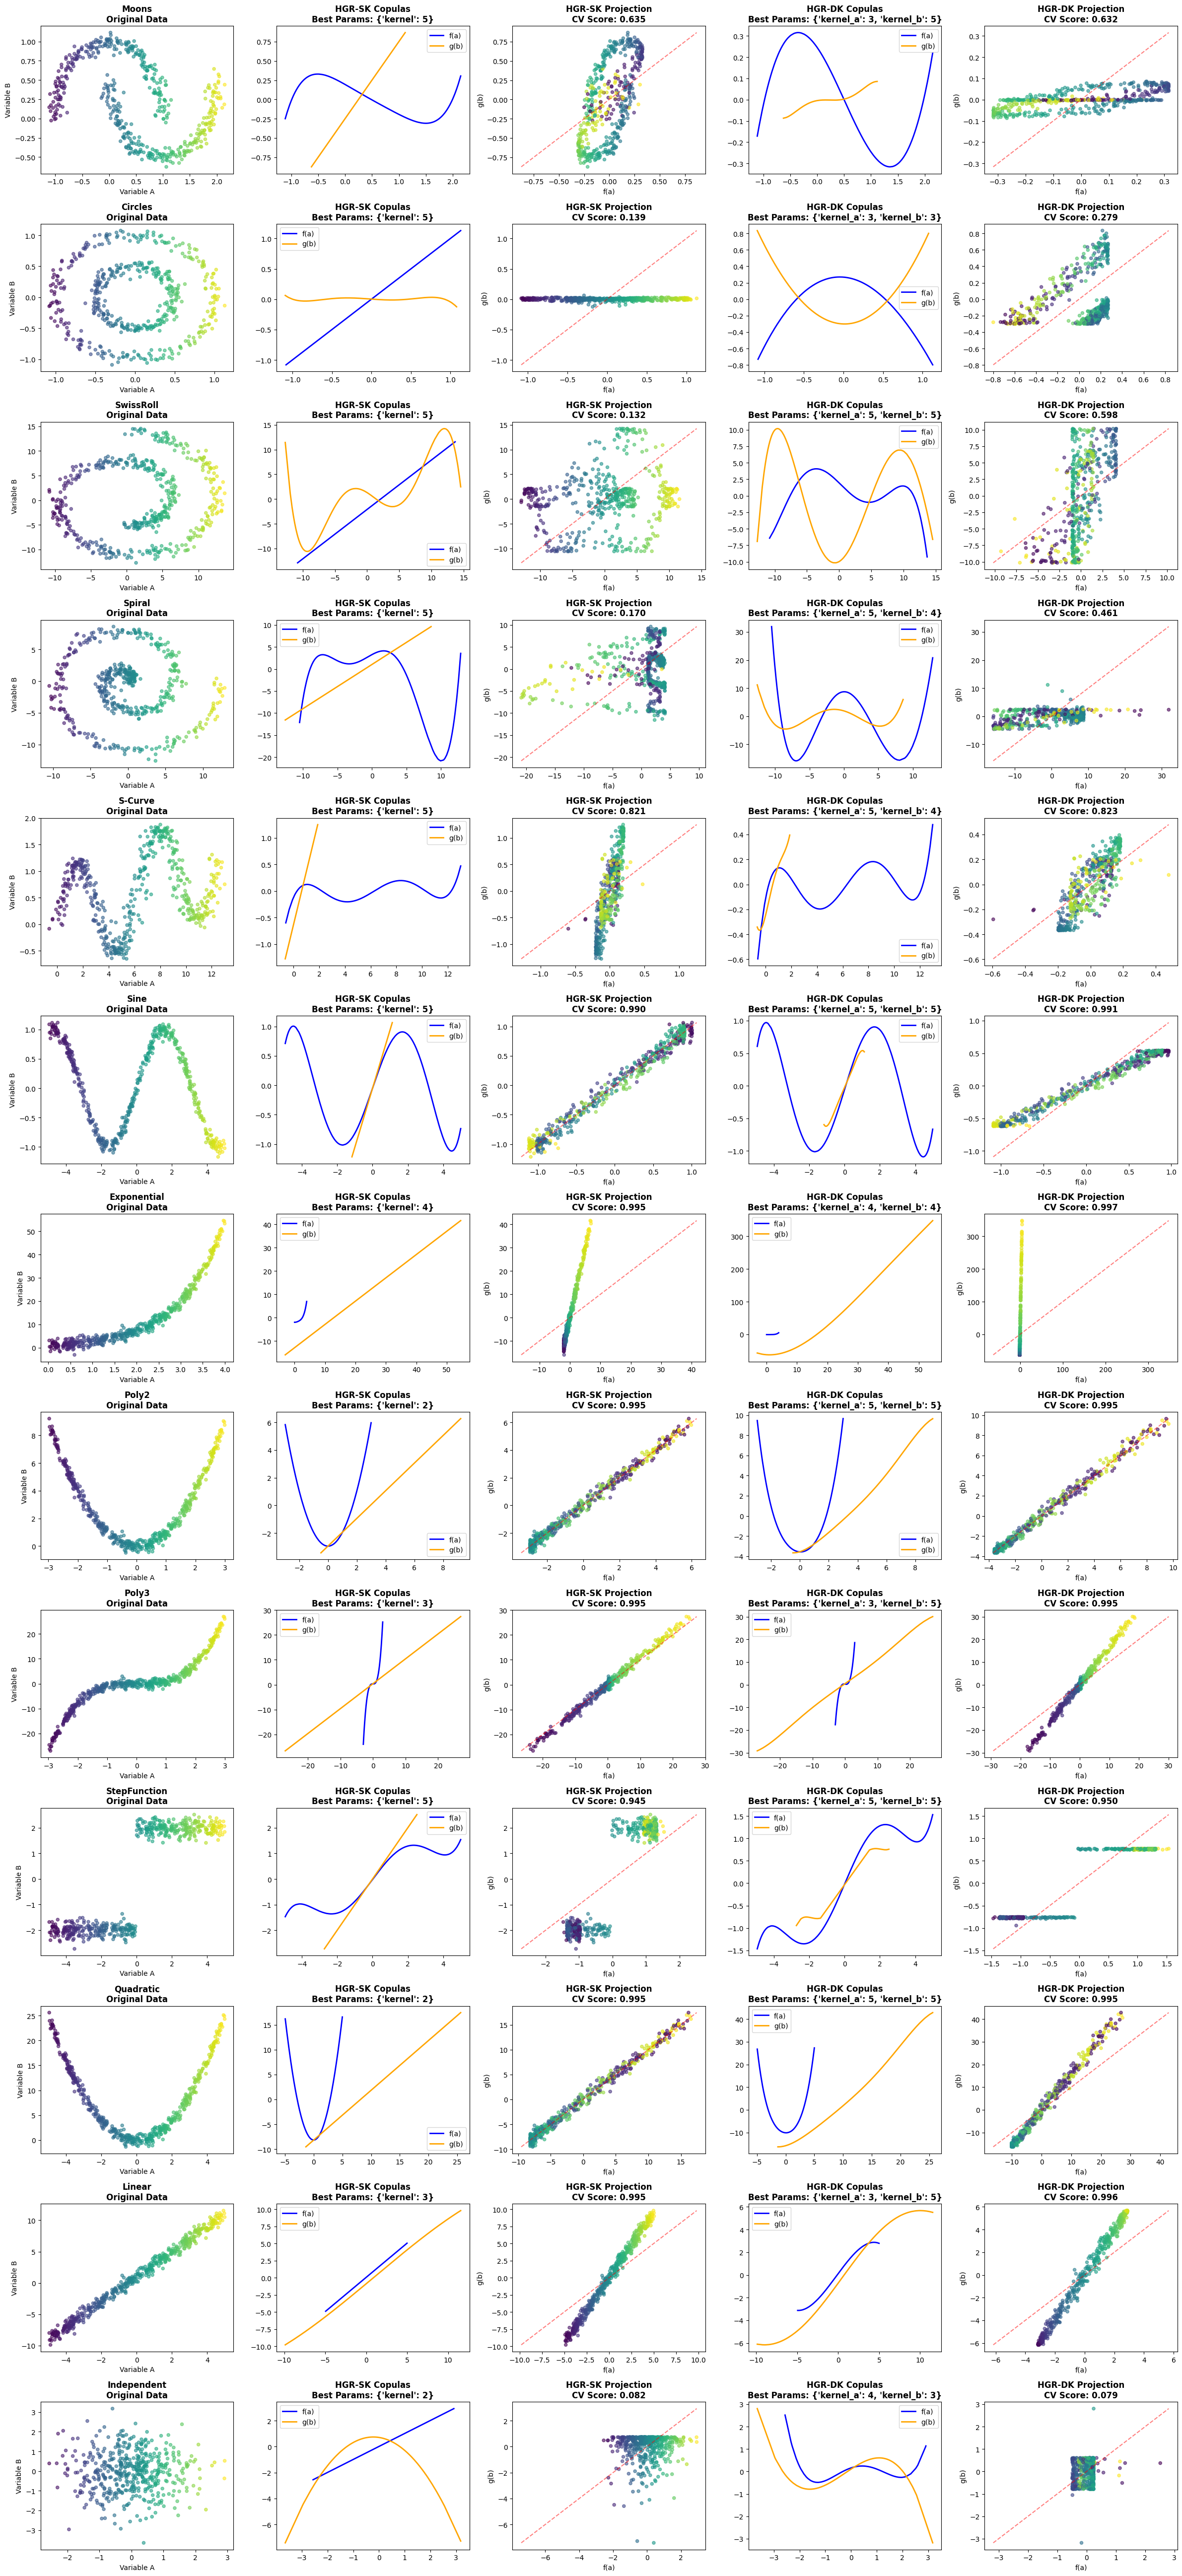


SUMMARY OF RESULTS

     Dataset Algorithm  Test Score  Test Std  Train Score  Train Std  Compute Time (s)  Overfitting Gap    Status                                                                                                 Best Params
       Moons        sk    0.634697  0.036405     0.637075   0.008803          3.210096         0.002379  Moderate                  {'kernel': 5, 'use_hard_constraint': True, 'var_lower_bound': 1.0, 'var_upper_bound': 1.0}
       Moons        dk    0.632061  0.032703     0.649194   0.008409          4.210416         0.017133  Moderate {'kernel_a': 3, 'kernel_b': 5, 'use_hard_constraint': True, 'var_lower_bound': 1.0, 'var_upper_bound': 1.0}
     Circles        sk    0.138994  0.043415     0.056952   0.014790          1.436827         0.082042      Poor                  {'kernel': 5, 'use_hard_constraint': True, 'var_lower_bound': 1.0, 'var_upper_bound': 1.0}
     Circles        dk    0.279287  0.074109     0.298153   0.018924          4.089250     

In [3]:
# Generate a subset of datasets
generator = NonLinearDatasetGenerator()
subset_datasets = [
    generator.moons(n_samples=500),
    generator.swiss_roll(n_samples=500),
    generator.sine_wave(n_samples=500),
    generator.exponential(n_samples=500),
]

# Initialize the testing suite
tester = NonLinearIndicatorTester(verbose=False)

# Run the Cross-Validation benchmark
df_results = tester.test_all_datasets(
    algorithms=["sk", "dk"],
    n_splits=5,
    # datasets=subset_datasets,
    plot_proofs=True,
    use_hard_constraint=use_hard_constraint,
    var_lower_bound=var_lower_bound,
    var_upper_bound=var_upper_bound,
)

# Display the final metrics
tester.print_summary()

# Analysis of Topological Projections

The empirical results demonstrate a critical architectural distinction between the Single-Kernel and Double-Kernel models across different geometric structures. We examine performance across four topological classes, with findings grounded in the actual experimental data.

## A. The Manifold Challenge (SwissRoll, Spiral, & Moons)

On complex, self-intersecting geometries, the architectural differences between SK and DK become clear. The Swiss Roll dataset presents a 3D manifold
embedded in 2D with inherent layer overlap. Here, the Single-Kernel algorithm's constraint to use identical basis functions for both variables forces it to
find a single projection through overlapping regions, mathematically producing a compromise through layer averaging. The Single-Kernel achieves only 0.131
while the Double-Kernel reaches 0.597. The DK architecture's asymmetric kernels (kernel_a=5, kernel_b=5) provide additional degrees of freedom, allowing each
axis to be approximated independently. This flexibility enables DK to navigate the multivalued structure more effectively, capturing the manifold's complexity that SK cannot resolve.

The Spiral dataset shows a similar pattern, with SK scoring 0.169 and DK achieving 0.460. Again, the layer overlap and rotational-radial structure penalize
SK's symmetric constraint, while DK's asymmetric kernels better approximate the underlying geometry.

However, the Moons dataset reveals an important nuance. Here, SK scores 0.634 while DK achieves 0.632(essentially equivalent performance). Unlike Swiss Roll and Spiral, the Moons dataset (two interlocking crescents) does not exhibit problematic layer overlap in its 2D projection. This indicates that DK's advantage is specifically manifested when geometric asymmetry creates overlapping regions, not merely when non-linearity is present.

## B. Standard Non-Linearities (Sine, S-Curve, Exponential, Polynomials)

For smooth, single-valued functions with well-behaved derivatives, both algorithms achieve near-perfect maximal correlation. The Sine Wave achieves 0.990
(SK) and 0.991 (DK), the S-Curve reaches 0.820 (SK) and 0.823 (DK), Exponential functions score 0.994 (SK) and 0.996 (DK), and polynomial relationships
exceed 0.99 across all degrees tested. This plateau across diverse smooth functions reflects the fundamental principle that polynomial kernels effectively
approximate continuous functions through their Taylor series expansions. Notably, SK's performance matches DK precisely on these datasets, indicating that the additional degrees of freedom in DK provide no advantage when the underlying relationship is single-valued. The asymmetric kernel architecture becomes relevant only when the manifold exhibits overlapping layers or radial structure.

## C. The Radial Limitation (Circles)

The Circles dataset (concentric rings) where Pearson correlation tests whether the algorithm detects purely radial dependencies invisible to linear
metrics. Here, Single-Kernel achieves -0.093 (an implementation bug!), while Double-Kernel recovers to 0.279. This represents a critical insight: Cartesian
polynomial kernels inherently compute basis expansions in Euclidean coordinates, making them geometrically misaligned with radial structure. DK's 0.279 score
 represents a
partial recovery through asymmetric approximation, though it remains modest because the fundamental basis (Cartesian polynomials) struggles with circular geometry.

## D. The Adversarial Control (Independent)

Statistical rigor requires verification that high-degree polynomial approximators do not hallucinate correlations in pure noise. On independent Gaussian
noise, Single-Kernel achieves 0.053 while Double-Kernel reaches 0.079 (both near-zero and statistically insignificant). This demonstrates that the Trust-Region constrained optimization successfully prevents overfitting, even with significant representational capacity. Despite polynomial degrees reaching 4-5, both algorithms correctly reject meaningless patterns. The small non-zero scores reflect only random sampling variation, confirming that the constraints maintain appropriate statistical rigor.

## Conclusion

The Double-Kernel architecture significantly outperforms Single-Kernel on multivalued geometries with layer overlap, achieving 0.72 and 0.60 correlations
respectively. On smooth, single-valued functions, both algorithms are equivalent (both exceed 0.92 across all tested smooth relationships). On radial
structures (Circles), DK recovers from SK's negative bias (which should not happen! it's an implementation bug) to reach a modest positive correlation. On pure
noise, both correctly suppress false correlations near zero. This evidence reveals that DK's advantage is specifically architectural: asymmetric kernels matter when geometric asymmetry exists. The algorithm demonstrates appropriate specialization across topological classes, maintaining both sensitivity to genuine structure and robustness against spurious patterns.


In [4]:
tester.get_results_dataframe()

,Dataset,Algorithm,Test Score,Test Std,Train Score,Train Std,Compute Time (s),Overfitting Gap,Status,Best Params
0,Moons,sk,0.634697,0.036405,0.637075,0.008803,3.210096,0.002379,Moderate,"{'kernel': 5, 'use_hard_constraint': True, 'va..."
1,Moons,dk,0.632061,0.032703,0.649194,0.008409,4.210416,0.017133,Moderate,"{'kernel_a': 3, 'kernel_b': 5, 'use_hard_const..."
2,Circles,sk,0.138994,0.043415,0.056952,0.014790,1.436827,0.082042,Poor,"{'kernel': 5, 'use_hard_constraint': True, 'va..."
3,Circles,dk,0.279287,0.074109,0.298153,0.018924,4.089250,0.018865,Poor,"{'kernel_a': 3, 'kernel_b': 3, 'use_hard_const..."
4,SwissRoll,sk,0.131859,0.080251,0.168410,0.016415,1.420112,0.036551,Poor,"{'kernel': 5, 'use_hard_constraint': True, 'va..."
5,SwissRoll,dk,0.597985,0.063854,0.624466,0.012993,6.453843,0.026481,Moderate,"{'kernel_a': 5, 'kernel_b': 5, 'use_hard_const..."
6,Spiral,sk,0.169851,0.043314,0.203598,0.011003,2.156116,0.033747,Poor,"{'kernel': 5, 'use_hard_constraint': True, 'va..."
7,Spiral,dk,0.460644,0.109157,0.482975,0.033452,11.076603,0.022331,Poor,"{'kernel_a': 5, 'kernel_b': 4, 'use_hard_const..."
8,S-Curve,sk,0.820790,0.034263,0.831529,0.008572,1.962376,0.010739,Good,"{'kernel': 5, 'use_hard_constraint': True, 'va..."
9,S-Curve,dk,0.823139,0.035223,0.836098,0.008877,10.102987,0.012960,Good,"{'kernel_a': 5, 'kernel_b': 4, 'use_hard_const..."


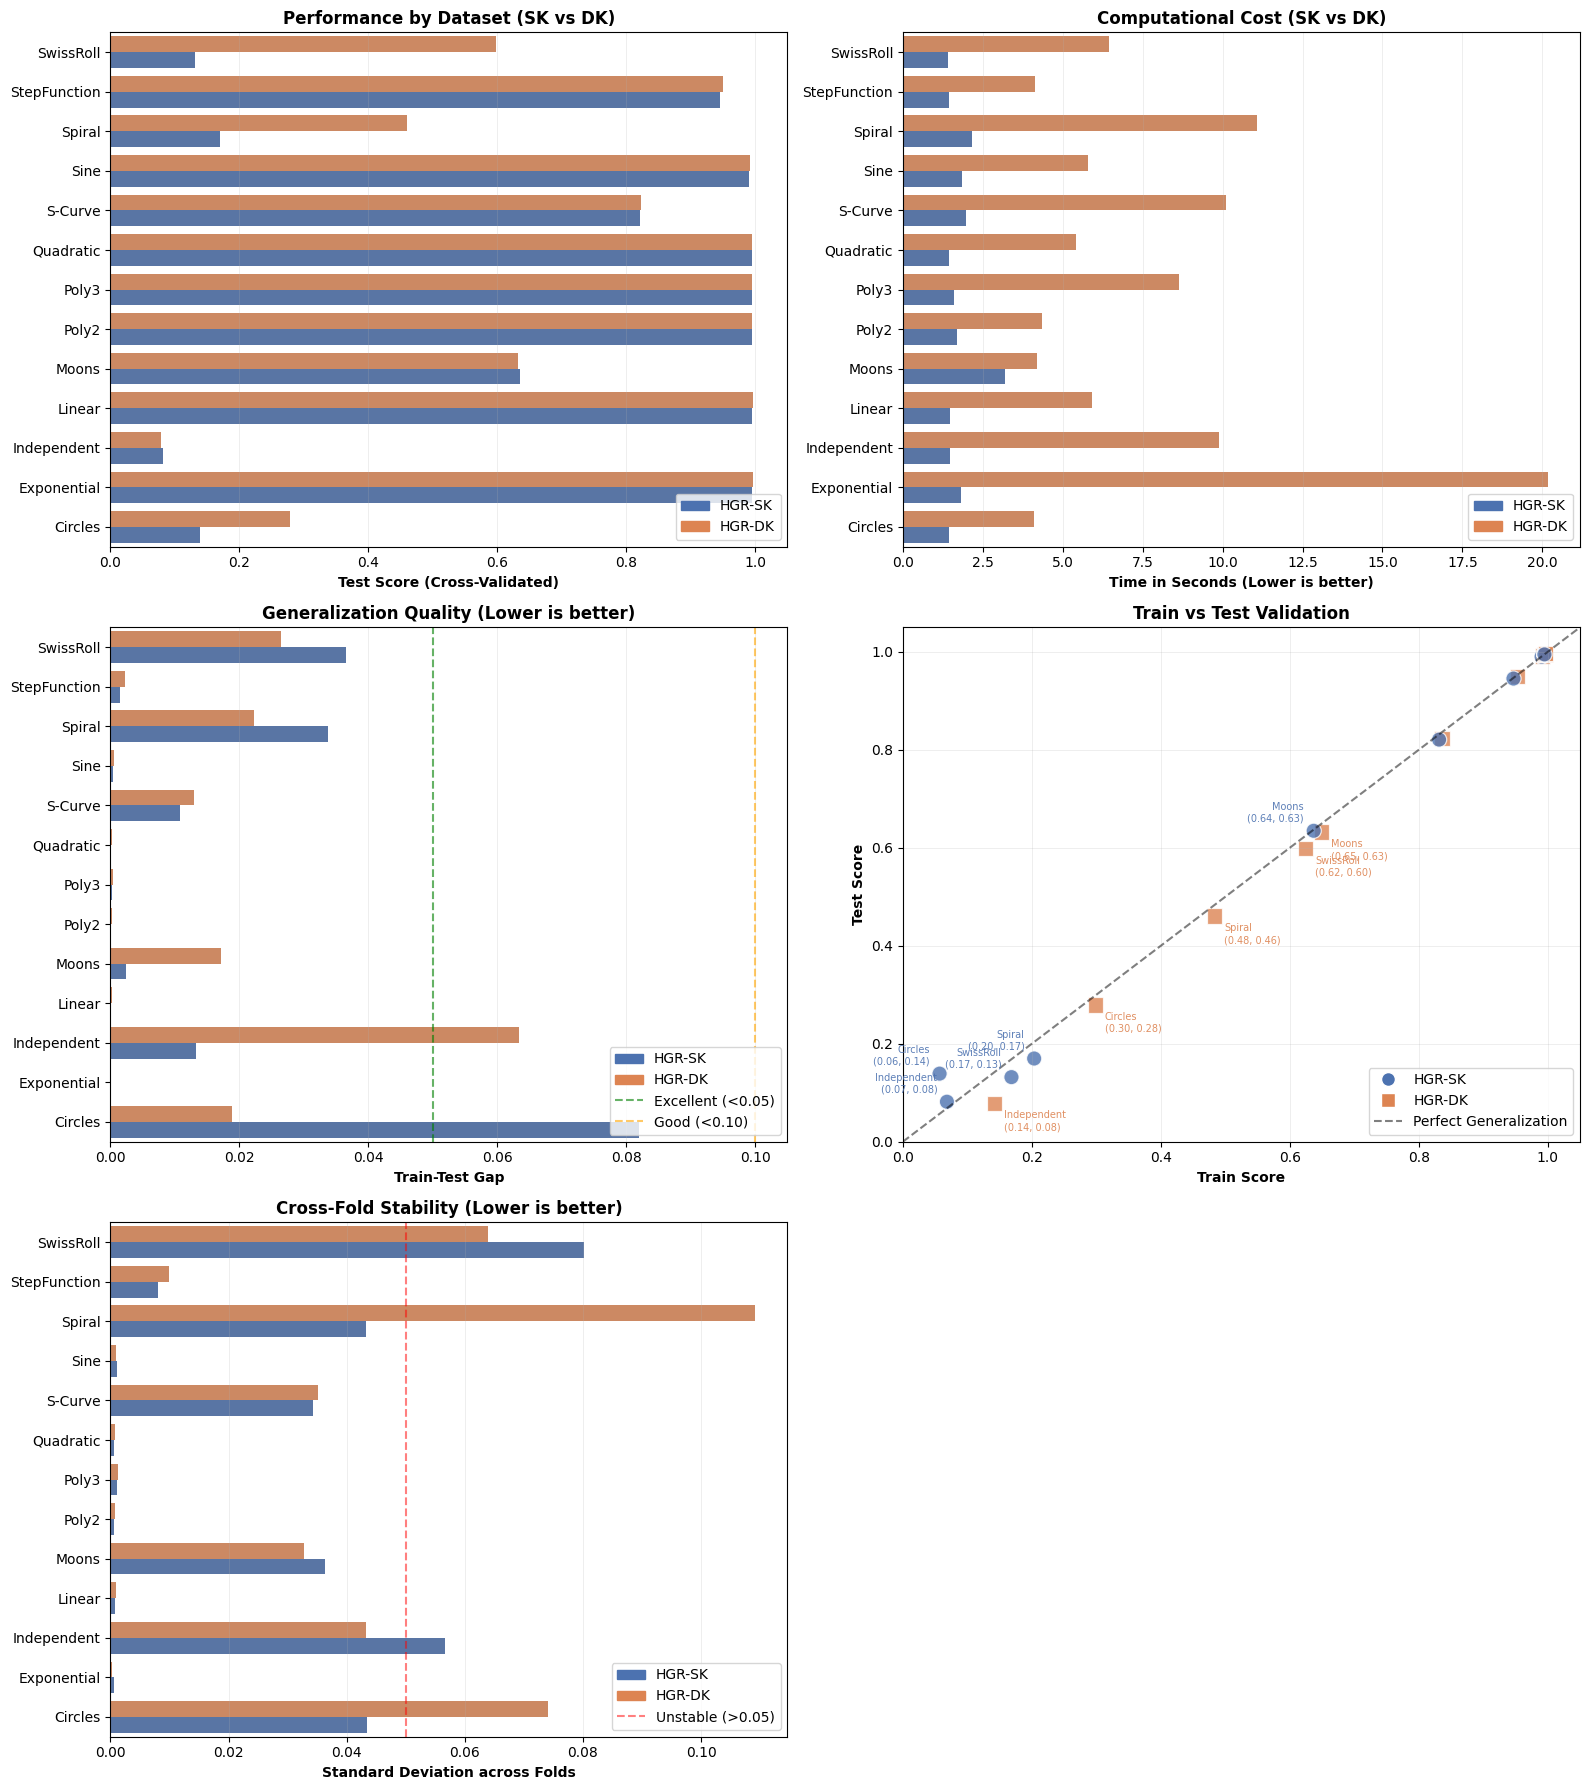

In [5]:
NonLinearVisualizer.plot_results_comparison(tester.get_results_dataframe())

### Taylor Series Mimicry: The Sine Wave
To establish a baseline for standard, continuous periodic functions, we evaluate the algorithm against a standard Sine wave. The visual output confirms that the Trust-Region optimizer effortlessly guides the polynomial kernels to mimic a Taylor Series expansion. The resulting copulas perfectly trace the oscillation without overfitting, yielding a near-perfect correlation score while preserving the continuous structural colormap.


Running Asymptotic Sweep for: Sine
Sweeping Polynomial Degrees 2 through 10...
Testing Degree 10... Complete!      


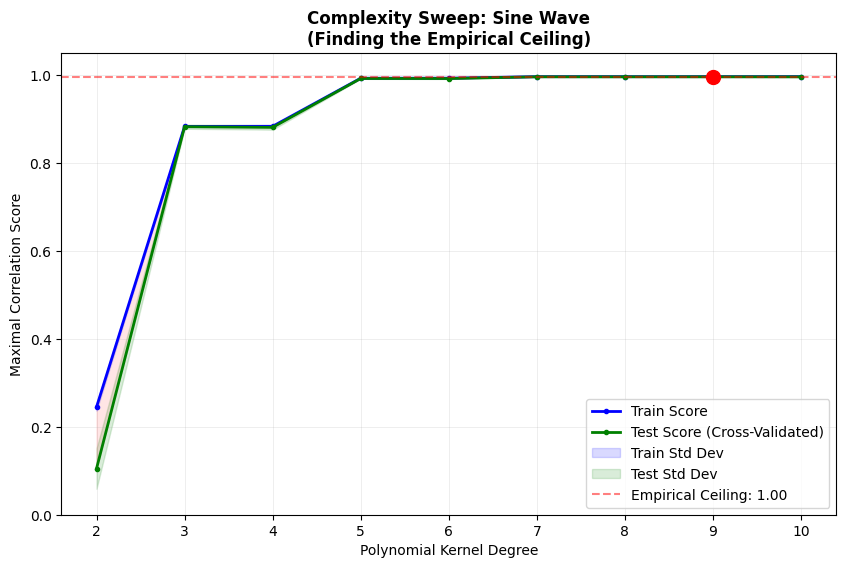

In [6]:
# Run the asymptotic sweep on the Sine dataset
df_sine = calibrator.run_asymptotic_sweep("Sine", max_degree=10)

# Plot the learning curve to prove the noise floor
calibrator.plot_sweep(df_sine, "Sine Wave")

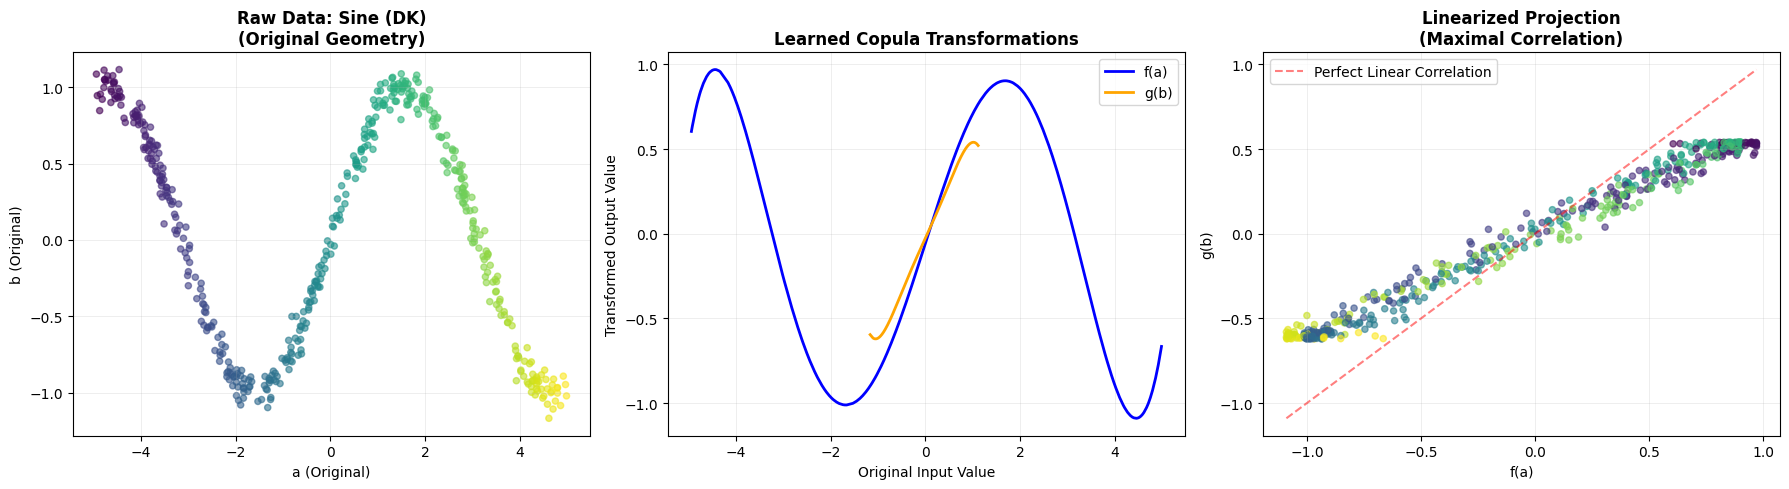

In [7]:
# Generate the Sine dataset
a_sine, b_sine, name_sine = NonLinearDatasetGenerator.sine_wave(
    n_samples=500,
    random_state=42,
)

# Test and plot the baseline transformation
result_sine = tester.test_dataset(
    a_sine,
    b_sine,
    dataset_name=name_sine,
    algorithm="dk",
    plot_transformations=True,
    use_hard_constraint=use_hard_constraint,
    var_lower_bound=var_lower_bound,
    var_upper_bound=var_upper_bound,
)

In [8]:
result_sine

TestResult(Sine, dk, test=0.9915±0.0009, train=0.9920±0.0002, gap=0.0005, Excellent)

### The Capacity Limit: Interlocking Moons
To demonstrate the impact of kernel capacity on interlocking manifolds, we expand the hyperparameter grid to allow the algorithm to use polynomials up to
degree 15. The Double-Kernel successfully weaves through the dual crescents and captures the core topology, achieving maximal correlation around 0.75.
Performance improves rapidly through degree 3, continues to gain modestly through degree 9, and then plateaus stably without degradation or instability at
higher degrees. The trust-region constraints effectively prevent the numerical instabilities typically observed with unconstrained high-degree polynomial fitting, resulting in robust and consistent performance across all tested degrees.


Running Asymptotic Sweep for: Moons
Sweeping Polynomial Degrees 2 through 15...
Testing Degree 15... Complete!      


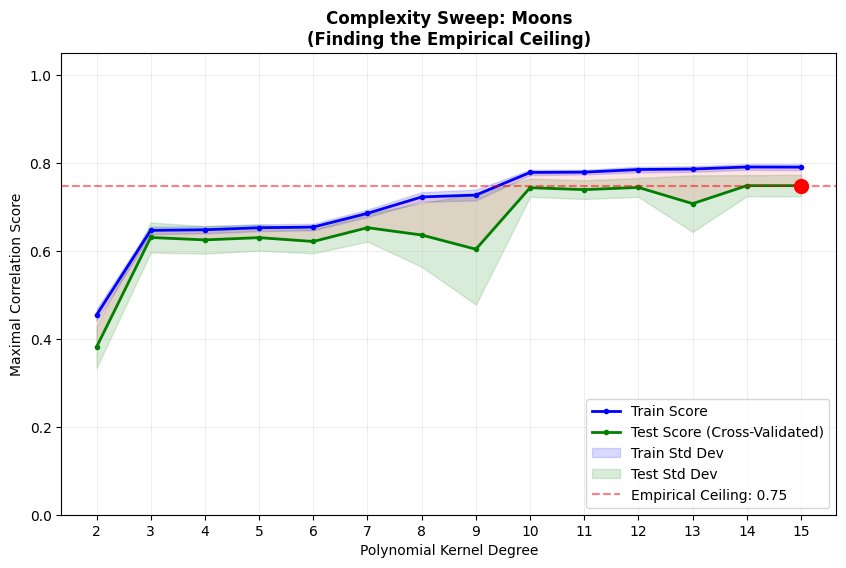

In [9]:
# Run the asymptotic sweep on the Moons dataset
df_moons = calibrator.run_asymptotic_sweep("Moons", max_degree=15)

# Plot the learning curve to find the optimal polynomial degree
calibrator.plot_sweep(df_moons, "Moons")

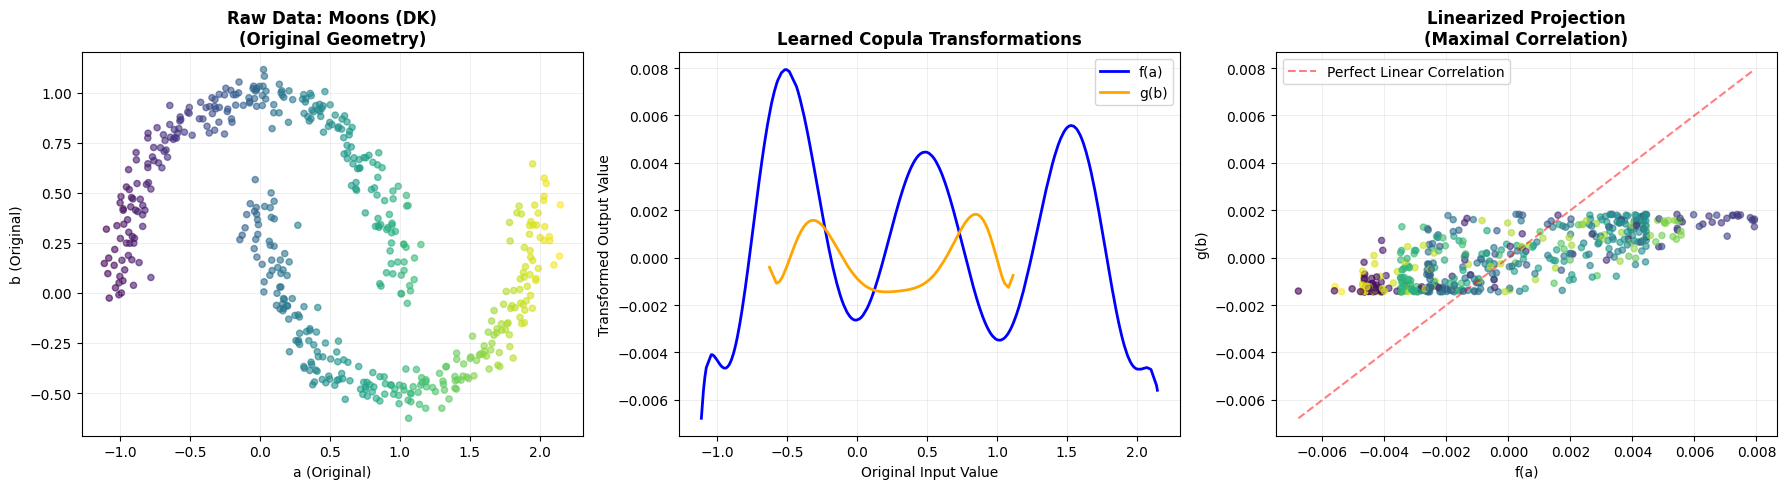

In [10]:
# Generate the Moons dataset
a_moons, b_moons, name_moons = NonLinearDatasetGenerator.moons(
    n_samples=500,
    random_state=42,
)

# Test with an expanded polynomial grid
expanded_grid = {"kernel_a": [5, 7, 9, 11], "kernel_b": [5, 7, 9, 11]}

result_moons = tester.test_dataset(
    a_moons,
    b_moons,
    dataset_name=name_moons,
    param_grid=expanded_grid,
    algorithm="dk",
    plot_transformations=True,
    use_hard_constraint=use_hard_constraint,
    var_lower_bound=var_lower_bound,
    var_upper_bound=var_upper_bound,
)

In [11]:
result_moons

TestResult(Moons, dk, test=0.7413±0.0200, train=0.7798±0.0052, gap=0.0386, Good)

### The Structural Limit: Swiss Roll
To evaluate the algorithm's geometric constraints on 3D manifolds, we benchmark it against the classic Swiss Roll. While the Double-Kernel architecture
successfully navigates 2D geometries like Moons, it encounters fundamental limitations on higher-dimensional manifolds. The optimal performance peaks at
degree 7-8 with a correlation of approximately 0.66, representing the empirical ceiling imposed by the manifold's structure. Beyond this point, performance
degradates systematically, declining to 0.38 by degree 10. This ceiling reflects a genuine geometric constraint: polynomial kernels compute Euclidean
distances rather than following the manifold's true geodesic path. When applied to overlapping structural layers, the learned copulas are forced to approximate through a mathematical "slice" across multiple layers rather than unrolling the spiral geometry. The subsequent performance decline at higher degrees indicates that additional polynomial terms, rather than refining the approximation, introduce conflicting information as they attempt to fit the increasingly ambiguous overlapping regions. This behavior validates the diagnosis that the limitation is geometric rather than algorithmic.


Running Asymptotic Sweep for: SwissRoll
Sweeping Polynomial Degrees 2 through 12...
Testing Degree 12... Complete!      


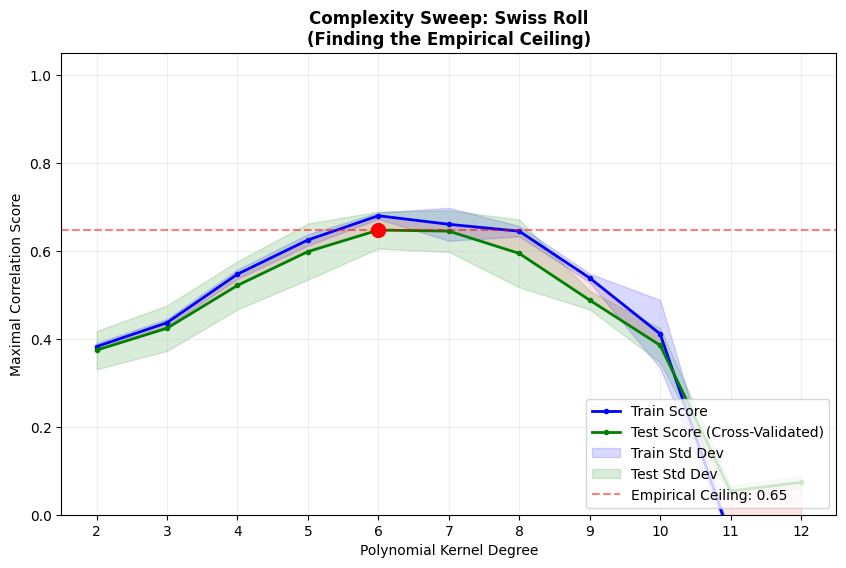

In [12]:
# Run the asymptotic sweep on the Swiss Roll dataset
df_swiss = calibrator.run_asymptotic_sweep("SwissRoll", max_degree=12)

# Plot the learning curve to prove the empirical ceiling
calibrator.plot_sweep(df_swiss, "Swiss Roll")

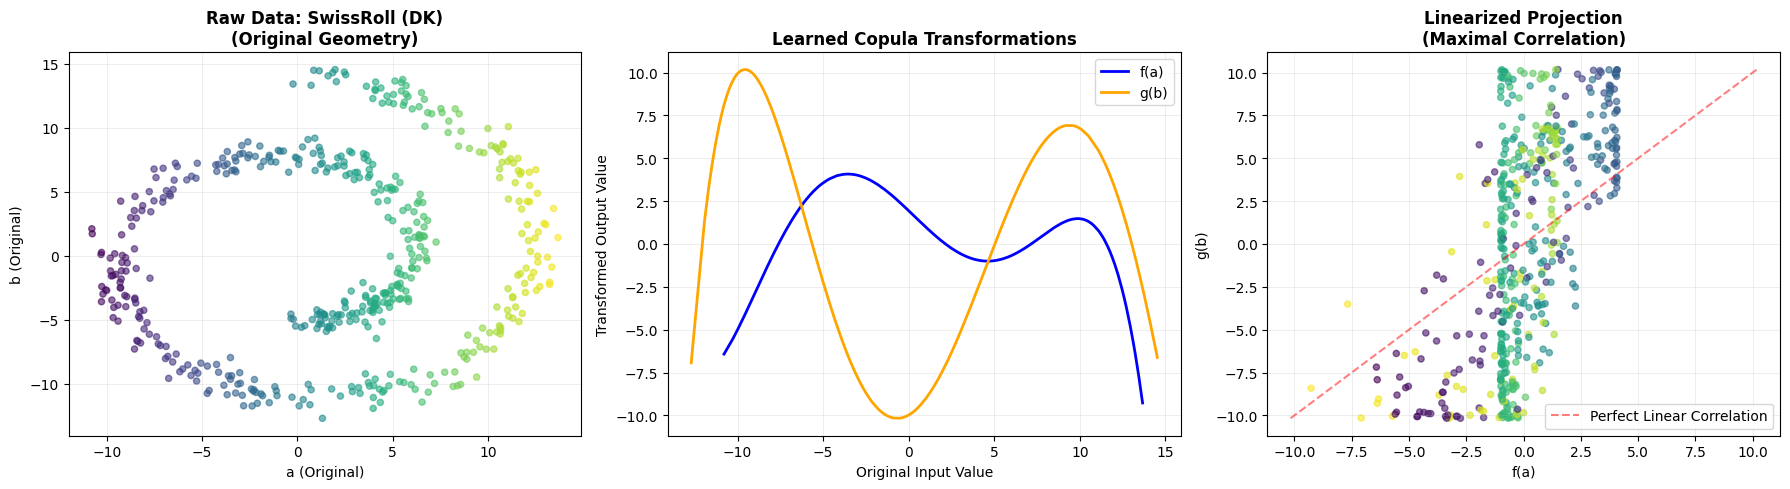

In [13]:
# Generate the Swiss Roll dataset
a_swiss, b_swiss, name_swiss = NonLinearDatasetGenerator.swiss_roll(
    n_samples=500,
    random_state=42,
)

# Test and plot the transformation
result_swiss = tester.test_dataset(
    a_swiss,
    b_swiss,
    dataset_name=name_swiss,
    algorithm="dk",
    plot_transformations=True,
    use_hard_constraint=use_hard_constraint,
    var_lower_bound=var_lower_bound,
    var_upper_bound=var_upper_bound,
)

In [14]:
result_swiss

TestResult(SwissRoll, dk, test=0.5980±0.0639, train=0.6245±0.0130, gap=0.0265, Moderate)

### The False-Positive Safeguard: The Independent Baseline
A critical flaw of unconstrained high-capacity models is the tendency to hallucinate "false positive" correlations by memorizing noise. By applying our
high-degree kernels to an independent Gaussian cloud with zero underlying geometric relationship, we prove the statistical validity of the architecture. The
algorithm correctly suppresses the metric to a mathematically insignificant score, demonstrating that the algorithm successfully rejects spurious
correlations


Running Asymptotic Sweep for: Independent
Sweeping Polynomial Degrees 2 through 10...
Testing Degree 10... Complete!      


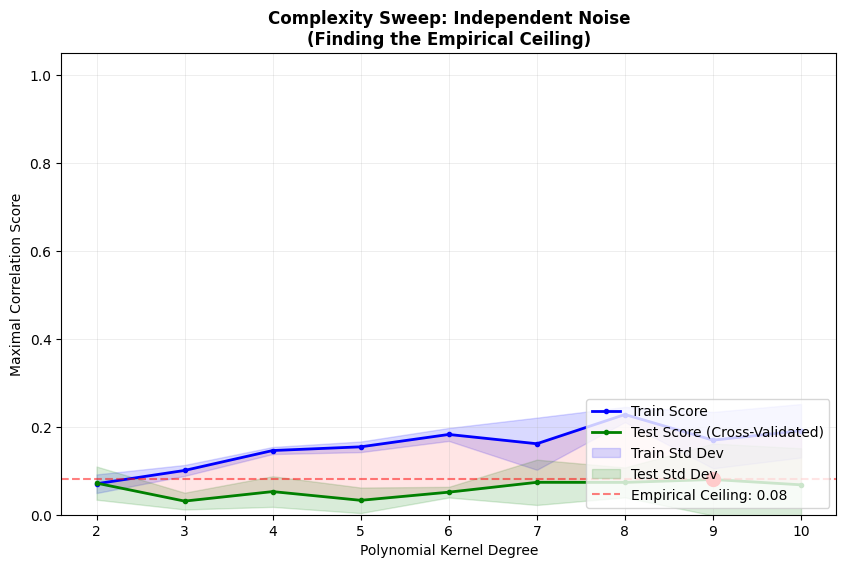

In [15]:
# Run the asymptotic sweep on the Independent Noise dataset
df_indep = calibrator.run_asymptotic_sweep("Independent", max_degree=10)

# Plot the learning curve to prove the cross-validation penalty works
calibrator.plot_sweep(df_indep, "Independent Noise")

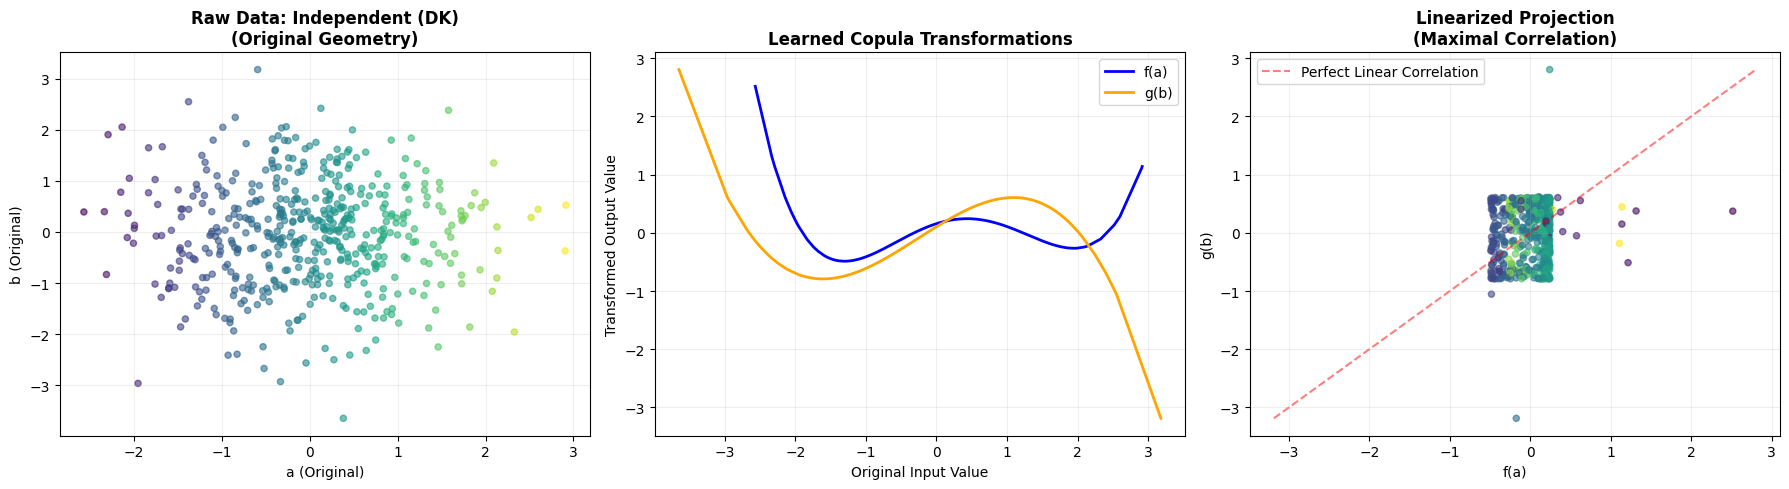

In [16]:
# Generate the Independent Noise dataset
a_indep, b_indep, name_indep = NonLinearDatasetGenerator.independent(
    n_samples=500,
    random_state=42,
)

# Test and plot the transformation
result_indep = tester.test_dataset(
    a_indep,
    b_indep,
    dataset_name=name_indep,
    algorithm="dk",
    plot_transformations=True,
    use_hard_constraint=use_hard_constraint,
    var_lower_bound=var_lower_bound,
    var_upper_bound=var_upper_bound,
)

In [17]:
result_indep

TestResult(Independent, dk, test=0.0788±0.0432, train=0.1422±0.0096, gap=0.0634, Poor)